### Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne 
from scipy.io import loadmat # loads .mat files
from scipy.signal import butter, filtfilt, welch
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report


### Loading Dataset

#### Multi channel EEG data

In [3]:
data = loadmat(r"E:\Milind\Milind_BCS_SecyTask_2026\Milind_NeuroDecoder\STEW Dataset\dataset.mat")

data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'dataset'])

In [4]:
eeg = data['dataset']

eeg.shape # channels x time_points x trials

(14, 19200, 45)

In [5]:
eeg[:,:,:]

array([[[4584.62, 4663.59, 4212.82, ..., 4233.33, 4502.05, 4105.13],
        [4584.1 , 4663.59, 4213.85, ..., 4225.13, 4502.05, 4109.23],
        [4574.36, 4658.46, 4228.21, ..., 4213.85, 4496.41, 4115.9 ],
        ...,
        [4605.64, 4717.95, 4168.72, ..., 4216.41, 4523.59, 4227.18],
        [4606.15, 4736.92, 4186.67, ..., 4220.51, 4518.46, 4223.59],
        [4611.28, 4746.15, 4202.05, ..., 4231.79, 4517.95, 4215.38]],

       [[3902.05, 3978.46, 4148.72, ..., 4220.  , 4781.03, 4028.72],
        [3895.9 , 3965.64, 4151.28, ..., 4206.67, 4778.46, 4027.69],
        [3893.85, 3965.64, 4155.38, ..., 4194.87, 4769.23, 4029.23],
        ...,
        [3987.69, 4144.62, 4217.44, ..., 4201.54, 4770.77, 4101.54],
        [3992.82, 4164.1 , 4224.62, ..., 4202.56, 4773.33, 4098.46],
        [4001.54, 4134.36, 4231.79, ..., 4206.15, 4779.49, 4086.15]],

       [[4571.79, 4641.03, 3766.15, ..., 3715.9 , 4411.79, 4111.79],
        [4574.87, 4643.08, 3768.21, ..., 3715.9 , 4412.31, 4121.54],
    

#### Labels

In [6]:
labels_data = loadmat(r"E:\Milind\Milind_BCS_SecyTask_2026\Milind_NeuroDecoder\STEW Dataset\class_012.mat")
labels_data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'class_012'])

In [7]:
labels = labels_data['class_012']
labels

array([[2],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [2],
       [2],
       [1],
       [0],
       [2],
       [1],
       [2],
       [0],
       [0],
       [2],
       [0],
       [1],
       [1],
       [2],
       [1],
       [1],
       [0],
       [2],
       [0],
       [2],
       [2],
       [0],
       [2],
       [0],
       [1],
       [1],
       [2],
       [2],
       [1],
       [2],
       [1]], dtype=uint8)

In [8]:
# 0 -> Low cognitive Load(class 0)
# 1,2 -> High cognitive Load(class 1)

binary_labels = (labels>0).astype(int).flatten()

binary_labels
# problem simplifies to binary classification


array([1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       1])

### High Pass Filter

In [32]:
def highpass_filter(signal, cutoff=0.5, fs=128, order=4):
    nyquist = fs/2
    normal_cutoff = cutoff/nyquist
    b, a = butter(order, normal_cutoff, btype='high')
    return filtfilt(b, a, signal)

filtered_eeg = np.zeros_like(eeg, dtype=np.float64)

for subject in range(eeg.shape[2]):
    for channel in range(eeg.shape[0]):
        filtered_eeg[channel, :, subject] = highpass_filter(eeg[channel, :, subject])

print(f"Amplitude range: [{filtered_eeg.min():.2f}, {filtered_eeg.max():.2f}]")

Amplitude range: [-7186.69, 6731.32]


In [10]:
filtered_eeg.shape

(14, 19200, 45)

### Epoching

In [ ]:
fs = 128 # sampling frequency -> samples in 1 sec from a signal 
epoch_size = 256   # each epoch = 2 seconds of EEG data
epochs = []
epoch_labels = []

num_epochs = filtered_eeg.shape[1] // epoch_size

for subject in range(filtered_eeg.shape[2]):
    subject_data = filtered_eeg[:, :, subject]
    
    for i in range(num_epochs):

        start = i * epoch_size
        end = start + epoch_size

        epoch = subject_data[:, start:end] # epoch shape is (14,256)
        epochs.append(epoch)

        # assign subject label to all epochs
        epoch_labels.append(binary_labels[subject])
epochs = np.array(epochs)
epoch_labels = np.array(epoch_labels)

In [12]:
epochs.shape # (len(epochs),channels,sample size of each epoch )

(3375, 14, 256)

In [13]:

clean_epochs = []
clean_labels = []
for i in range(len(epochs)): # len(epoch)=3375
    epoch = epochs[i] # epoch -> (14,256)
    if np.max(np.abs(epoch)) <= 100: # Keep only epochs where all signal values are within |100| microvolts
        clean_epochs.append(epoch)
        clean_labels.append(epoch_labels[i])

clean_epochs = np.array(clean_epochs)
clean_labels = np.array(clean_labels)
# clean EEG signal has smaller amplitude and smoother signals 

In [14]:
clean_epochs.shape # (number of clean epochs,EEG channels, time samples in each epoch)

(1132, 14, 256)

In [15]:
def bandpower(signal, fs, band):

    freqs, psd = welch(signal, fs, nperseg=fs*2)
    idx = np.logical_and(freqs >= band[0], freqs <= band[1])

    return np.mean(psd[idx])


In [16]:
def hjorth_parameters(signal):

    first_deriv = np.diff(signal)
    second_deriv = np.diff(first_deriv)
    var_zero = np.var(signal)
    var_d1 = np.var(first_deriv)
    var_d2 = np.var(second_deriv)
    activity = var_zero
    mobility = np.sqrt(var_d1 / var_zero)
    complexity = (np.sqrt(var_d2 / var_d1))/mobility

    return activity, mobility, complexity


In [34]:
clean_epochs.shape

(1132, 14, 256)

In [17]:
theta_band = (4, 8)

alpha_band = (8, 13)

features = []

for epoch in clean_epochs:

    theta_powers = []

    alpha_powers = []

    for channel in epoch:

        theta_power = bandpower(channel,fs,theta_band)
        alpha_power = bandpower(channel,fs,alpha_band)

        theta_powers.append(theta_power)
        alpha_powers.append(alpha_power)

    theta_mean = np.mean(theta_powers)
    alpha_mean = np.mean(alpha_powers)

    ratio = theta_mean / (alpha_mean + 1e-6)

    activity, mobility, complexity = hjorth_parameters(epoch.flatten())

    feature_vector = [
        theta_mean,
        alpha_mean,
        ratio,
        activity,
        mobility,
        complexity
    ]

    features.append(feature_vector)

X = np.array(features)
y = clean_labels
print("Feature Matrix Shape :", X.shape)

Feature Matrix Shape : (1132, 6)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [20]:

pipeline = Pipeline([ ("scaler", StandardScaler()), ("classifier", RandomForestClassifier( n_estimators=100, random_state=42, n_jobs=-1))])

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')

print("Cross Validation Scores :")
print(cv_scores)

print("Mean CV Accuracy :")
print(cv_scores.mean())


Cross Validation Scores :
[0.7092511  0.74449339 0.76548673 0.71238938 0.74778761]
Mean CV Accuracy :
0.735881642041246


In [22]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [23]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)


Accuracy : 0.73568281938326
Precision : 0.7755102040816326
Recall : 0.9047619047619048


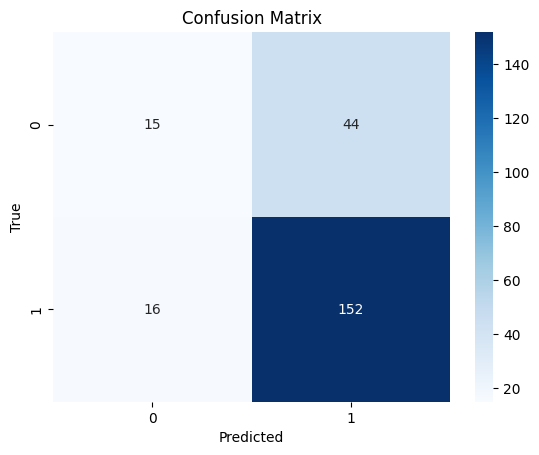

In [24]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap( cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [25]:
model = pipeline.named_steps['classifier']

feature_names = [
    "Theta",
    "Alpha",
    "Theta/Alpha",
    "Activity",
    "Mobility",
    "Complexity"
]

importances = model.feature_importances_
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

print("Feature Importance :")
print(importance_df)


Feature Importance :
       Feature  Importance
3     Activity    0.194985
1        Alpha    0.174630
5   Complexity    0.171124
4     Mobility    0.162935
2  Theta/Alpha    0.151366
0        Theta    0.144960


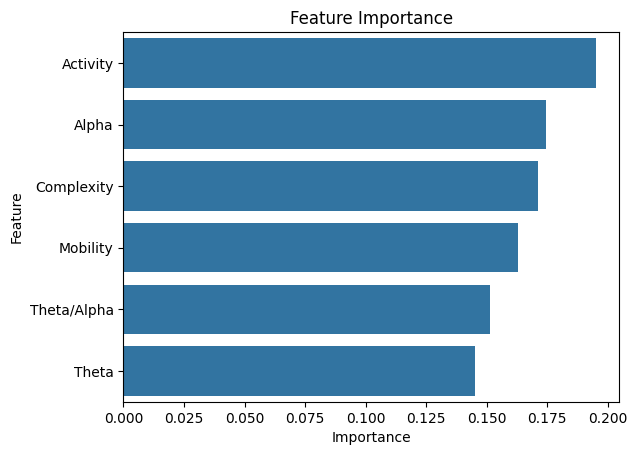

In [45]:
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance")
plt.show()

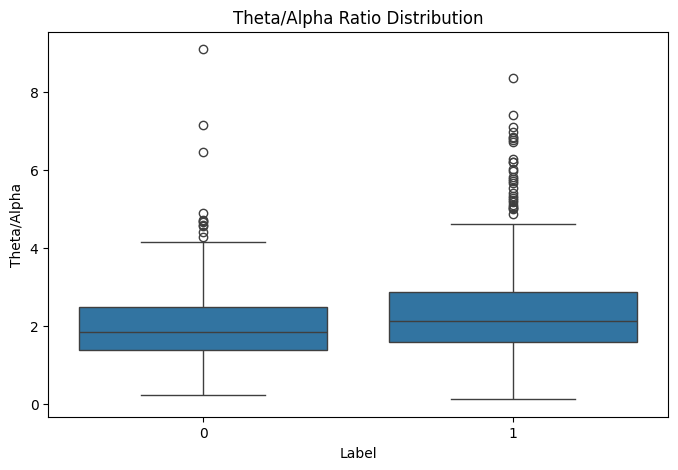

In [27]:
feature_df = pd.DataFrame(X, columns=feature_names)
feature_df["Label"] = y
plt.figure(figsize=(8,5))
sns.boxplot(x="Label", y="Theta/Alpha", data=feature_df)
plt.title("Theta/Alpha Ratio Distribution")
plt.show()

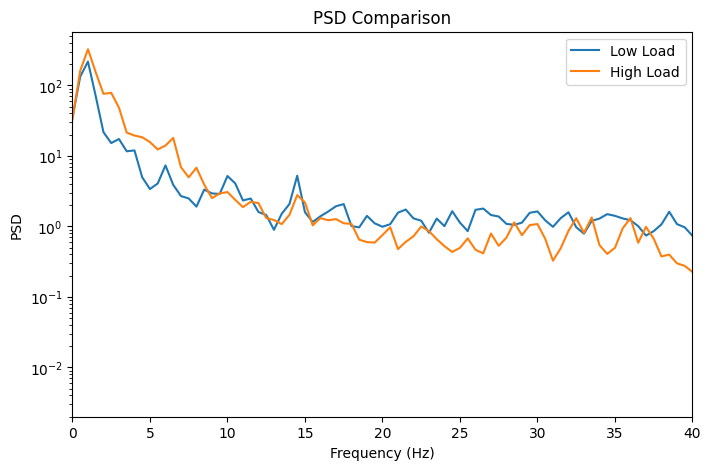

Pipeline Complete


In [ ]:
low_epoch = clean_epochs[y == 0][0].flatten() # belonging to class 0

high_epoch = clean_epochs[y == 1][0].flatten() # belonging to class 1

freqs_low, psd_low = welch(low_epoch, fs)

freqs_high, psd_high = welch(high_epoch, fs)

plt.figure(figsize=(8,5))
plt.semilogy(freqs_low, psd_low, label="Low Load")

plt.semilogy(freqs_high, psd_high, label="High Load")
plt.xlim(0, 40)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("PSD Comparison")
plt.legend()
plt.show()
print("Pipeline Complete")